In [5]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("..")
from particle_utils import extinction_efficiency, scattering_efficiency, single_scattering_albedo
from particle_utils import scattering_cross_section_rayleigh_sphere, absorption_cross_section_rayleigh_sphere

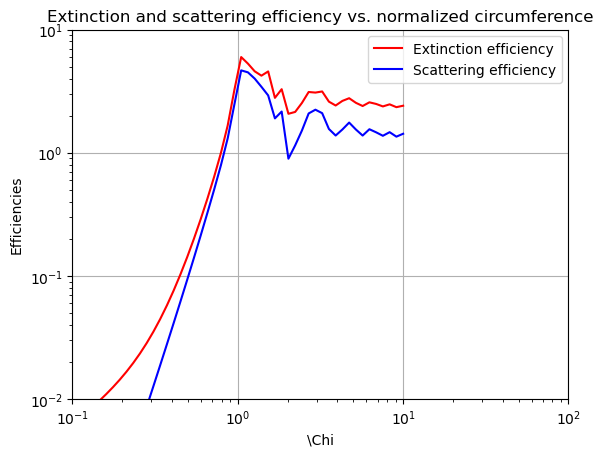

In [6]:
# Ulaby2014, Fig8-19, p345
epsr = 8-0.5j
Chis = np.logspace(-1, 1, 50)   # normalized circumference
Num = len(Chis)
ext_effs = np.zeros(Num)
sca_effs = np.zeros(Num)
for i in range(Num):
    ext_effs[i] = extinction_efficiency(epsr, Chis[i])
    sca_effs[i] = scattering_efficiency(epsr, Chis[i])
plt.loglog(Chis, ext_effs, 'r-', label='Extinction efficiency')
plt.loglog(Chis, sca_effs, 'b-', label='Scattering efficiency')
plt.xlabel('\Chi')
plt.ylabel('Efficiencies')
plt.legend()
plt.xlim(0.1, 100)
plt.ylim(0.01, 10)
plt.grid()
plt.title('Extinction and scattering efficiency vs. normalized circumference')
plt.show()

In [7]:
# epsr = 3.2 - 3.2j
# Chis = np.logspace(-1, 1, 50)
# Num = len(Chis)
# ssas = np.zeros(Num)
# sca_effs = np.zeros(Num)
# for i in range(Num):
#     ssas[i] = single_scattering_albedo(epsr, Chis[i])
# plt.loglog(Chis, ssas, 'r-', label='SSA')
# plt.xlabel('\Chi')
# plt.ylabel('SSA')
# plt.legend()
# plt.xlim(0.1, 100)
# plt.ylim(0.01, 10)
# plt.grid()
# plt.title('Single scattering albedo vs. normalized circumference')
# plt.show()

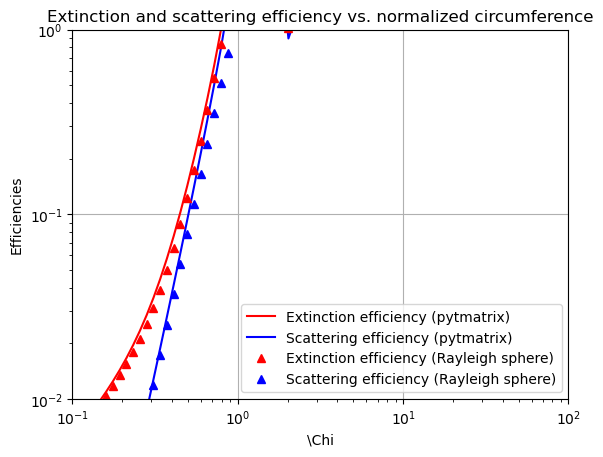

In [8]:
# Ulaby2014, Fig8-19, p345 / Compare T-matrix with Rayleigh sphere approximation
Lambda = 1
A = np.pi * (Chis * Lambda / (2* np.pi))**2
sca_effs2 = scattering_cross_section_rayleigh_sphere(Lambda, epsr, Chis) / A
a_effs = absorption_cross_section_rayleigh_sphere(Lambda, epsr, Chis) / A
ext_effs2 = sca_effs + a_effs

plt.loglog(Chis, ext_effs, 'r-', label='Extinction efficiency (pytmatrix)')
plt.loglog(Chis, sca_effs, 'b-', label='Scattering efficiency (pytmatrix)')
plt.loglog(Chis, ext_effs2, 'r^', label='Extinction efficiency (Rayleigh sphere)')
plt.loglog(Chis, sca_effs2, 'b^', label='Scattering efficiency (Rayleigh sphere)')
plt.xlabel('\Chi')
plt.ylabel('Efficiencies')
plt.legend()
plt.xlim(0.1, 100)
plt.ylim(0.01, 1)
plt.grid()
plt.title('Extinction and scattering efficiency vs. normalized circumference')
plt.show()